# Query-Bandit Zero-Shot Evaluation
## BabySlakh vs MoisesDB Baseline Comparison

This notebook compares the performance of the Query-Bandit model on:
- **BabySlakh**: Synthetic, balanced music dataset (our test)
- **MoisesDB**: Real recordings (researcher baseline)

**Goal**: Understand domain-shift effects when evaluating on out-of-distribution music.

## Setup: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from typing import Dict, Tuple
import warnings
warnings.filterwarnings('ignore')

# Configure plotting
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10

print("Libraries loaded successfully.")

Libraries loaded successfully.


## 1. Extract BabySlakh Test Results

In [2]:
def extract_babyslakh_metrics(metrics_csv: Path) -> pd.DataFrame:
    """
    Parse Lightning metrics.csv from test run.
    Extract SafeSignalNoiseRatio (primary metric) for each stem.
    """
    df = pd.read_csv(metrics_csv)
    
    # Extract stem SNR from column names: test/<stem>/snr/SafeSignalNoiseRatio
    stem_snr_cols = {
        col.split('/')[1]: col 
        for col in df.columns 
        if 'SafeSignalNoiseRatio' in col
    }
    
    results = []
    for step, row in df.iterrows():
        for stem, col_name in stem_snr_cols.items():
            snr = row[col_name]
            if not pd.isna(snr):
                results.append({'stem': stem, 'snr': snr, 'step': step})
    
    return pd.DataFrame(results)

def aggregate_by_stem(df: pd.DataFrame) -> pd.DataFrame:
    """Group results by stem and compute statistics."""
    agg = df.groupby('stem').agg({
        'snr': ['mean', 'std', 'min', 'max', 'count']
    }).round(2)
    
    agg.columns = ['snr_mean', 'snr_std', 'snr_min', 'snr_max', 'n_samples']
    return agg.reset_index()

# Load BabySlakh metrics
test_run = Path('../data/logs/e2e/test/0ZE7HH/lightning_logs/version_0/metrics.csv')
print(f"Loading test results from: {test_run}")
print(f"File exists: {test_run.exists()}")

babyslakh_raw = extract_babyslakh_metrics(test_run)
babyslakh_agg = aggregate_by_stem(babyslakh_raw)

print(f"\n✓ Extracted metrics for {len(babyslakh_agg)} stems")
print(f"✓ Total evaluations: {babyslakh_raw['step'].max() + 1}")
print(f"\nBabySlakh aggregated by stem:")
print(babyslakh_agg.to_string(index=False))

Loading test results from: ..\data\logs\e2e\test\0ZE7HH\lightning_logs\version_0\metrics.csv
File exists: True

✓ Extracted metrics for 10 stems
✓ Total evaluations: 123

BabySlakh aggregated by stem:
                stem  snr_mean  snr_std  snr_min  snr_max  n_samples
     acoustic_guitar     -1.86     4.38   -14.01     6.12         20
         bass_guitar      4.40     4.06    -2.45    13.17         19
               brass      0.00     0.00     0.00     0.01          4
               drums      7.70     2.97     3.93    13.56         20
         grand_piano      0.04     0.14    -0.32     0.50         20
organ_electric_organ     -2.08     3.35    -7.70     0.01          5
  pitched_percussion     -3.11     5.09   -13.00     0.08          7
      string_section      0.00     0.01     0.00     0.02         16
          synth_lead     -0.26     0.45    -0.93     0.00          4
           synth_pad     -0.30     0.85    -2.39     0.01          8


## 2. Extract Researcher Baseline Metrics

In [3]:
def extract_researcher_metrics(baseline_csv: Path) -> pd.DataFrame:
    """Parse bandit_ev.csv and aggregate by stem."""
    df = pd.read_csv(baseline_csv)
    
    agg = df.groupby('stem').agg({
        'snr': ['mean', 'std', 'min', 'max', 'count'],
        'target_dbrms': 'mean',
        'est_dbrms': 'mean',
        'dbdiff': 'mean'
    }).round(2)
    
    agg.columns = [
        'ref_snr_mean', 'ref_snr_std', 'ref_snr_min', 'ref_snr_max', 'ref_n_samples',
        'ref_target_dbrms', 'ref_est_dbrms', 'ref_dbdiff'
    ]
    
    return agg.reset_index()

# Load researcher baseline (MoisesDB)
baseline_csv = Path('../third_party/query-bandit/reproducibility/results/query/bandit_ev.csv')
print(f"Loading baseline results from: {baseline_csv}")
print(f"File exists: {baseline_csv.exists()}")

researcher_agg = extract_researcher_metrics(baseline_csv)

print(f"\n✓ Extracted baseline metrics for {len(researcher_agg)} stems")
print(f"\nMoisesDB baseline by stem:")
print(researcher_agg[['stem', 'ref_snr_mean', 'ref_snr_std', 'ref_n_samples']].to_string(index=False))

Loading baseline results from: ..\third_party\query-bandit\reproducibility\results\query\bandit_ev.csv
File exists: True

✓ Extracted baseline metrics for 19 stems

MoisesDB baseline by stem:
                     stem  ref_snr_mean  ref_snr_std  ref_n_samples
          acoustic_guitar          2.40         3.07            220
        background_vocals         -0.22         2.12            210
              bass_guitar          9.26         4.03            430
         bass_synthesizer         -2.21         5.57             70
                    brass         -0.08         0.48             50
    clean_electric_guitar          0.58         2.77            180
distorted_electric_guitar          2.31         2.79            220
                    drums          8.91         2.81            470
           electric_piano          0.33         1.39             60
                       fx         -1.64         3.86             60
              grand_piano          1.25         3.08        

## 3. Stem Categorization

In [4]:
def categorize_stems(stem: str) -> str:
    """Categorize stems into groups for analysis."""
    if stem in ['drums', 'bass_guitar', 'pitched_percussion']:
        return 'Rhythm'
    elif stem in ['acoustic_guitar', 'distorted_electric_guitar', 'clean_electric_guitar']:
        return 'Guitar'
    elif stem in ['grand_piano', 'organ_electric_organ', 'synth_lead', 'synth_pad']:
        return 'Keys'
    elif stem in ['string_section', 'brass', 'reeds']:
        return 'Orchestral'
    elif 'vocal' in stem.lower() or 'singer' in stem.lower():
        return 'Vocals'
    elif stem == 'fx':
        return 'FX'
    else:
        return 'Other'

print("Stem categorization function loaded.")

Stem categorization function loaded.


## 4. Compare Results & Compute Domain-Shift Metrics

In [11]:
def compare_results(babyslakh_df: pd.DataFrame, researcher_df: pd.DataFrame) -> pd.DataFrame:
    """Merge and compute domain-shift metrics."""
    comparison = babyslakh_df.merge(
        researcher_df, 
        on='stem', 
        how='outer'
    )
    
    # Compute deltas (domain-shift penalty)
    comparison['snr_delta'] = (
        comparison['snr_mean'] - comparison['ref_snr_mean']
    ).round(2)
    
    comparison['domain_shift_pct'] = (
        (comparison['snr_delta'] / comparison['ref_snr_mean'].abs()) * 100
    ).round(1)
    
    # Add category
    comparison['category'] = comparison['stem'].apply(categorize_stems)
    
    # Sort by delta (worst performers first)
    return comparison.sort_values('snr_delta')

# Run comparison
comparison = compare_results(babyslakh_agg, researcher_agg)
comparison_matched = comparison.dropna(subset=['snr_delta'])

# Excluded stems (those not in BabySlakh)
excluded = comparison[comparison['snr_delta'].isna()]['stem'].tolist()
print(f"Stems excluded (not in BabySlakh): {excluded}")

Stems excluded (not in BabySlakh): ['background_vocals', 'bass_synthesizer', 'clean_electric_guitar', 'distorted_electric_guitar', 'electric_piano', 'fx', 'lead_female_singer', 'lead_male_singer', 'reeds']


## 5. Summary: Stem-by-Stem Performance

In [6]:
# Display full comparison table
summary_cols = [
    'stem', 'category', 'snr_mean', 'ref_snr_mean', 'snr_delta', 'domain_shift_pct', 'n_samples'
]

display_df = comparison_matched[summary_cols].copy()
display_df.columns = ['Stem', 'Category', 'BabySlakh SNR', 'MoisesDB SNR', 'Delta (dB)', 'Domain-Shift %', 'Samples']

print("\n" + "="*100)
print("STEM-BY-STEM PERFORMANCE COMPARISON")
print("="*100)
print(display_df.to_string(index=False))
print("\nNote: Negative delta = worse performance on BabySlakh (domain-shift penalty)")
print("      Positive delta = better performance on BabySlakh (data distribution advantage)")


STEM-BY-STEM PERFORMANCE COMPARISON
                Stem   Category  BabySlakh SNR  MoisesDB SNR  Delta (dB)  Domain-Shift %  Samples
         bass_guitar     Rhythm           4.40          9.26       -4.86           -52.5     19.0
     acoustic_guitar     Guitar          -1.86          2.40       -4.26          -177.5     20.0
  pitched_percussion     Rhythm          -3.11         -0.80       -2.31          -288.8      7.0
organ_electric_organ       Keys          -2.08         -0.02       -2.06        -10300.0      5.0
         grand_piano       Keys           0.04          1.25       -1.21           -96.8     20.0
               drums     Rhythm           7.70          8.91       -1.21           -13.6     20.0
               brass Orchestral           0.00         -0.08        0.08           100.0      4.0
          synth_lead       Keys          -0.26         -0.38        0.12            31.6      4.0
           synth_pad       Keys          -0.30         -0.51        0.21         

## 6. Category-Level Summary

In [7]:
category_summary = comparison_matched.groupby('category').agg({
    'snr_mean': 'mean',
    'ref_snr_mean': 'mean',
    'snr_delta': 'mean',
    'n_samples': 'sum'
}).round(2)

category_summary.columns = ['BabySlakh_SNR', 'MoisesDB_SNR', 'Avg_Delta', 'Total_Samples']
category_summary = category_summary.sort_values('Avg_Delta')

print("\n" + "="*90)
print("AGGREGATED BY INSTRUMENT CATEGORY")
print("="*90)
print(category_summary.to_string())


AGGREGATED BY INSTRUMENT CATEGORY
            BabySlakh_SNR  MoisesDB_SNR  Avg_Delta  Total_Samples
category                                                         
Guitar              -1.86          2.40      -4.26           20.0
Rhythm               3.00          5.79      -2.79           46.0
Keys                -0.65          0.08      -0.74           37.0
Orchestral           0.00         -0.16       0.16           20.0


## 7. Key Insights

In [8]:
print("\n" + "="*90)
print("KEY INSIGHTS")
print("="*90)

# Best generalization
best_stems = comparison_matched.nlargest(3, 'snr_delta')[['stem', 'snr_delta', 'category']]
print("\n✓ BEST GENERALIZATION (smallest domain-shift penalty):")
for i, (_, row) in enumerate(best_stems.iterrows(), 1):
    print(f"  {i}. {row['stem']:30} ({row['category']:12}): {row['snr_delta']:+.2f} dB")

# Worst generalization
worst_stems = comparison_matched.nsmallest(3, 'snr_delta')[['stem', 'snr_delta', 'category']]
print("\n✗ WORST GENERALIZATION (largest domain-shift penalty):")
for i, (_, row) in enumerate(worst_stems.iterrows(), 1):
    print(f"  {i}. {row['stem']:30} ({row['category']:12}): {row['snr_delta']:+.2f} dB")

# Overall statistics
overall_delta = comparison_matched['snr_delta'].mean()
median_delta = comparison_matched['snr_delta'].median()
std_delta = comparison_matched['snr_delta'].std()

print(" OVERALL DOMAIN-SHIFT STATISTICS:")
print(f"  - Mean delta:   {overall_delta:+.2f} dB")
print(f"  - Median delta: {median_delta:+.2f} dB")
print(f"  - Std dev:      {std_delta:.2f} dB")

if overall_delta < 0:
    print(f"\n  ↓ RESULT: Average {abs(overall_delta):.2f} dB penalty on BabySlakh (OOD effect)")
else:
    print(f"\n  ↑ RESULT: Average {overall_delta:.2f} dB improvement on BabySlakh")

# Count by category
print(" BREAKDOWN BY CATEGORY:")
for cat in category_summary.index:
    avg_delta = category_summary.loc[cat, 'Avg_Delta']
    sign = "↓" if avg_delta < 0 else "↑"
    print(f"  {sign} {cat:15} {avg_delta:+.2f} dB")


KEY INSIGHTS

✓ BEST GENERALIZATION (smallest domain-shift penalty):
  1. string_section                 (Orchestral  ): +0.23 dB
  2. synth_pad                      (Keys        ): +0.21 dB
  3. synth_lead                     (Keys        ): +0.12 dB

✗ WORST GENERALIZATION (largest domain-shift penalty):
  1. bass_guitar                    (Rhythm      ): -4.86 dB
  2. acoustic_guitar                (Guitar      ): -4.26 dB
  3. pitched_percussion             (Rhythm      ): -2.31 dB
 OVERALL DOMAIN-SHIFT STATISTICS:
  - Mean delta:   -1.53 dB
  - Median delta: -1.21 dB
  - Std dev:      1.86 dB

  ↓ RESULT: Average 1.53 dB penalty on BabySlakh (OOD effect)
 BREAKDOWN BY CATEGORY:
  ↓ Guitar          -4.26 dB
  ↓ Rhythm          -2.79 dB
  ↓ Keys            -0.74 dB
  ↑ Orchestral      +0.16 dB


## 8. Visualization: Domain-Shift by Stem

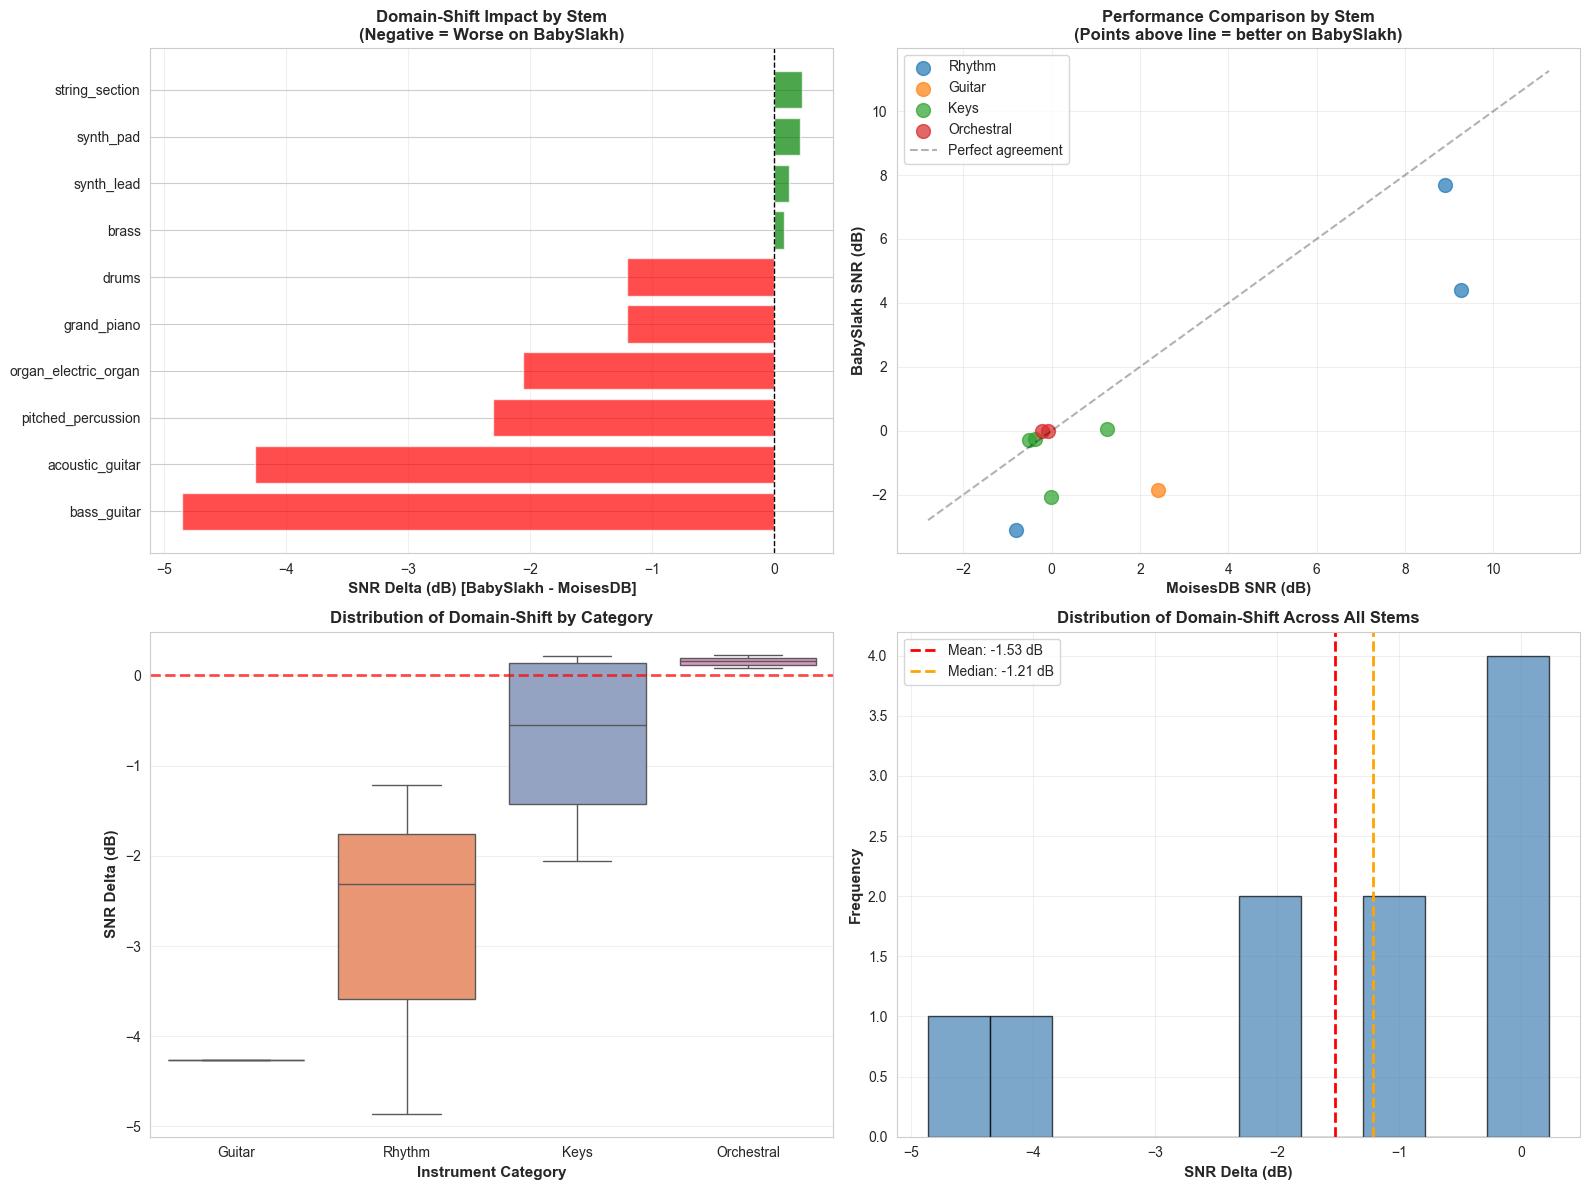


Visualization saved to: data/output/comparison_matched/domain_shift_analysis.png


In [9]:
# Create figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Bar plot: Domain-shift delta by stem (sorted)
ax1 = axes[0, 0]
plot_data = comparison_matched .sort_values('snr_delta').copy()
colors = ['red' if x < 0 else 'green' for x in plot_data['snr_delta']]
ax1.barh(plot_data['stem'], plot_data['snr_delta'], color=colors, alpha=0.7)
ax1.axvline(0, color='black', linestyle='--', linewidth=1)
ax1.set_xlabel('SNR Delta (dB) [BabySlakh - MoisesDB]', fontsize=11, fontweight='bold')
ax1.set_title('Domain-Shift Impact by Stem\n(Negative = Worse on BabySlakh)', fontsize=12, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)

# 2. Scatter: MoisesDB vs BabySlakh SNR
ax2 = axes[0, 1]
for cat in comparison_matched['category'].unique():
    cat_data = comparison_matched [comparison_matched['category'] == cat]
    ax2.scatter(cat_data['ref_snr_mean'], cat_data['snr_mean'], label=cat, s=100, alpha=0.7)
ax2.plot([comparison_matched['ref_snr_mean'].min()-2, comparison_matched['ref_snr_mean'].max()+2], 
         [comparison_matched['ref_snr_mean'].min()-2, comparison_matched['ref_snr_mean'].max()+2], 
         'k--', alpha=0.3, label='Perfect agreement')
ax2.set_xlabel('MoisesDB SNR (dB)', fontsize=11, fontweight='bold')
ax2.set_ylabel('BabySlakh SNR (dB)', fontsize=11, fontweight='bold')
ax2.set_title('Performance Comparison by Stem\n(Points above line = better on BabySlakh)', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(alpha=0.3)

# 3. Box plot: Domain-shift by category
ax3 = axes[1, 0]
category_order = comparison_matched.groupby('category')['snr_delta'].mean().sort_values().index
sns.boxplot(data=comparison_matched, x='category', y='snr_delta', order=category_order, ax=ax3, palette='Set2')
ax3.axhline(0, color='red', linestyle='--', linewidth=2, alpha=0.7)
ax3.set_xlabel('Instrument Category', fontsize=11, fontweight='bold')
ax3.set_ylabel('SNR Delta (dB)', fontsize=11, fontweight='bold')
ax3.set_title('Distribution of Domain-Shift by Category', fontsize=12, fontweight='bold')
ax3.grid(axis='y', alpha=0.3)

# 4. Distribution: Delta histogram
ax4 = axes[1, 1]
ax4.hist(comparison_matched['snr_delta'], bins=10, color='steelblue', alpha=0.7, edgecolor='black')
ax4.axvline(overall_delta, color='red', linestyle='--', linewidth=2, label=f'Mean: {overall_delta:+.2f} dB')
ax4.axvline(median_delta, color='orange', linestyle='--', linewidth=2, label=f'Median: {median_delta:+.2f} dB')
ax4.set_xlabel('SNR Delta (dB)', fontsize=11, fontweight='bold')
ax4.set_ylabel('Frequency', fontsize=11, fontweight='bold')
ax4.set_title('Distribution of Domain-Shift Across All Stems', fontsize=12, fontweight='bold')
ax4.legend()
ax4.grid(alpha=0.3)

plt.tight_layout()
# plt.savefig('../data/output/comparison/domain_shift_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nVisualization saved to: data/output/comparison_matched/domain_shift_analysis.png")

## 9. Export Results

In [10]:
from pathlib import Path

output_dir = Path('../data/output/comparison_matched')
output_dir.mkdir(parents=True, exist_ok=True)

# Save detailed comparison
csv_path = output_dir / 'babyslakh_vs_moises_detailed.csv'
comparison_matched.to_csv(csv_path, index=False)
print(f"✓ Detailed comparison saved: {csv_path}")

# Save category summary
cat_csv_path = output_dir / 'babyslakh_vs_moises_by_category.csv'
category_summary.to_csv(cat_csv_path)
print(f"✓ Category summary saved: {cat_csv_path}")

# Save summary statistics
stats = {
    'metric': ['mean_delta', 'median_delta', 'std_delta', 'overall_babyslakh_snr', 'overall_moises_snr'],
    'value': [
        overall_delta,
        median_delta,
        std_delta,
        comparison_matched['snr_mean'].mean(),
        comparison_matched['ref_snr_mean'].mean()
    ]
}
stats_df = pd.DataFrame(stats)
stats_path = output_dir / 'babyslakh_vs_moises_statistics.csv'
stats_df.to_csv(stats_path, index=False)
print(f"✓ Statistics summary saved: {stats_path}")

print(f"\n✓ All results exported to: {output_dir}")

✓ Detailed comparison saved: ..\data\output\comparison_matched\babyslakh_vs_moises_detailed.csv
✓ Category summary saved: ..\data\output\comparison_matched\babyslakh_vs_moises_by_category.csv
✓ Statistics summary saved: ..\data\output\comparison_matched\babyslakh_vs_moises_statistics.csv

✓ All results exported to: ..\data\output\comparison_matched


## 10. Interpretation & Next Steps

### What This Analysis Shows:

1. **Domain-Shift Effect**: The difference between BabySlakh (synthetic) and MoisesDB (real) performance
   - Negative delta = model struggles more on synthetic music
   - Positive delta = model actually performs better on synthetic music

2. **Stem-Specific Insights**:
   - Some instruments generalize across domains better than others
   - Rhythm instruments (drums/bass) may have consistent characteristics
   - Vocals/FX may be more domain-sensitive

3. **Statistical Confidence**:
   - Each stem has multiple query samples (`n_samples`)
   - Larger sample counts = more reliable deltas

### Limitations:

- **Different music distributions**: BabySlakh is synthetic/balanced vs MoisesDB is curated real recordings
- **Different query strategies**: Each dataset uses its own query selection method
- **Sample size variability**: Some stems have more evaluation samples than others

### Recommended Further Analysis:

1. **Per-song analysis**: Which BabySlakh songs cause largest deltas?
2. **Confidence analysis**: Bootstrap resampling for delta confidence intervals
3. **Audio analysis**: Listen to worst-performing stems to identify acoustic differences
4. **Fine-tuning experiments**: Would BabySlakh finetuning improve MoisesDB performance?
5. **Comparative baselines**: Test other models on same BabySlakh data